 =============================================================
  ##               TRABAJO FINAL INTEGRADOR       
  
  ###                VISIÓN POR COMPUTADORA II
  ###             Chest CT-Scan images Dataset 2025
 =============================================================


**ALUMNOS:**
- Mauro Fabian Barquinero
- Juan Cruz Ojeda
- Mariano Campos
- Jose Luis Perez Galindo

---

[ENLACE DATASET](https://www.kaggle.com/datasets/mohamedhanyyy/chest-ctscan-images)

### IMPORT

In [3]:
import os
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import matplotlib.image as mpimg
import numpy as np
import seaborn as sns
import shutil
import torch
import torch.nn as nn


from collections import defaultdict
from pathlib import Path

from torchvision.models import resnet50
import torch
from torchvision.models import densenet121


# Semilla para reproducibilidad de los experimentos
np.random.seed(42)
torch.manual_seed(42);

---

### ANALISIS DE LA ESTRUCTURA DEL DATASET

### Verificando las carpetas del dataset

In [2]:
# Path del directorio
data_dir = os.path.join(".", "Data")

# Verificamos que el directorio exista
if not os.path.exists(data_dir):
    raise FileNotFoundError(f"No se encontró el directorio: {data_dir}")

# Listar las clases dentro de cada subconjunto: train, test y valid
subsets = ['train', 'test', 'valid']

for subset in subsets:
    subset_path = os.path.join(data_dir, subset)
    if not os.path.exists(subset_path):
        print(f"[ADVERTENCIA] No se encontró el subdirectorio: {subset_path}")
        continue
    classes = os.listdir(subset_path)
    print(f"\n{subset.upper()}:")
    for cls in classes:
        print(f"  - {cls}")


TRAIN:
  - adenocarcinoma
  - large.cell.carcinoma
  - normal
  - squamous.cell.carcinoma

TEST:
  - adenocarcinoma
  - large.cell.carcinoma
  - normal
  - squamous.cell.carcinoma

VALID:
  - adenocarcinoma
  - large.cell.carcinoma
  - normal
  - squamous.cell.carcinoma


### Como podemos visualizar, los nombres por subtipo de cáncer varian. Se debería estandarizar los nombres.

 #### Se procede a visualizar las imágenes por clases.


📂 train/adenocarcinoma:


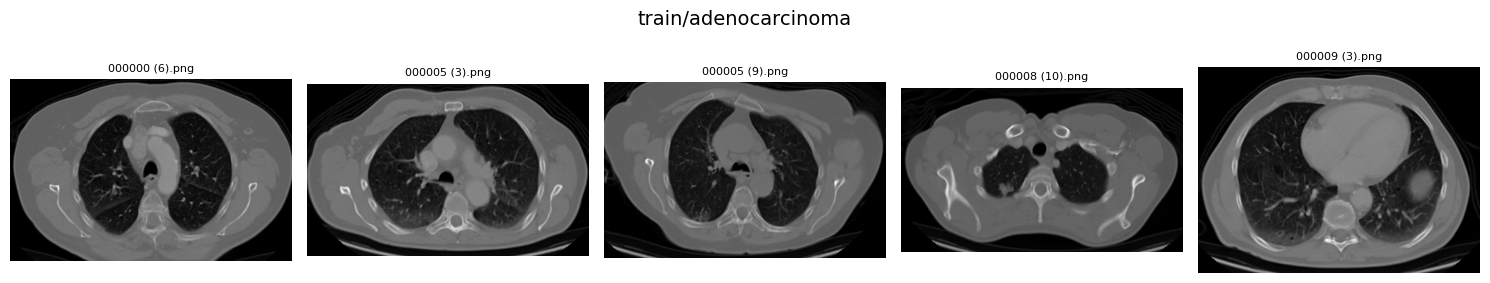


📂 train/large.cell.carcinoma:


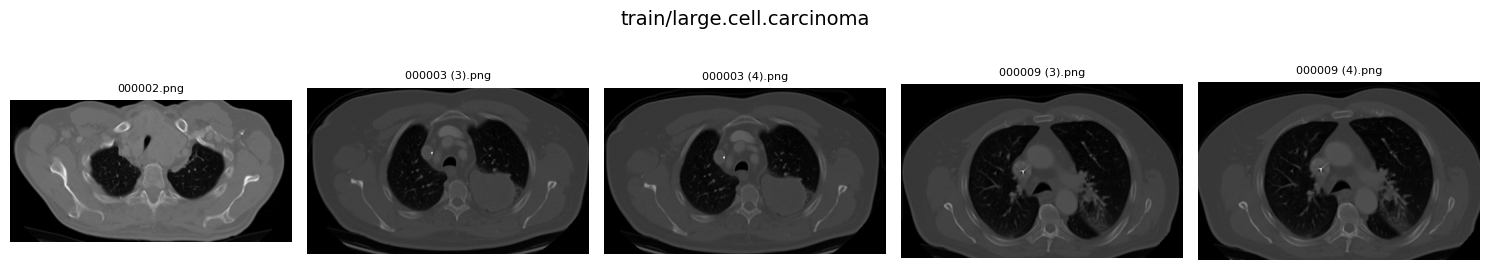


📂 train/normal:


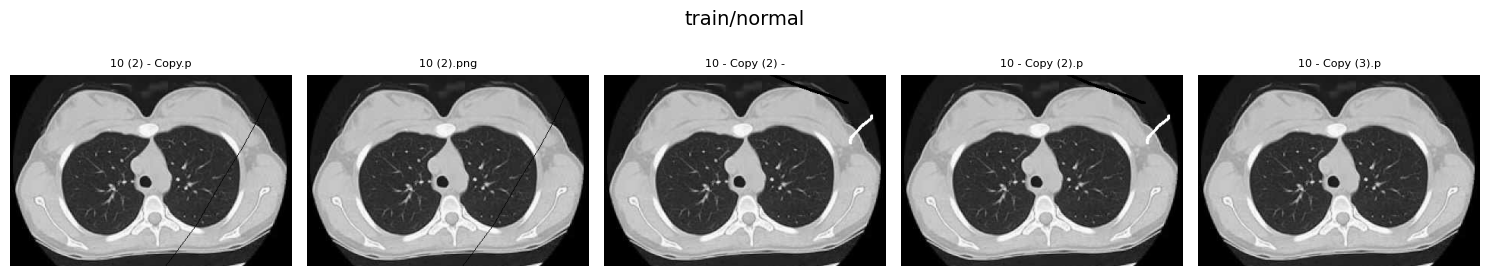


📂 train/squamous.cell.carcinoma:


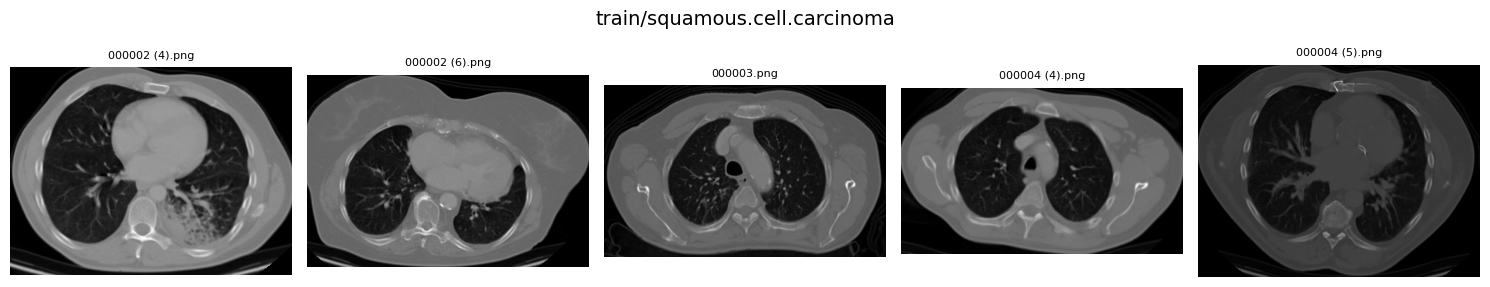


📂 valid/adenocarcinoma:


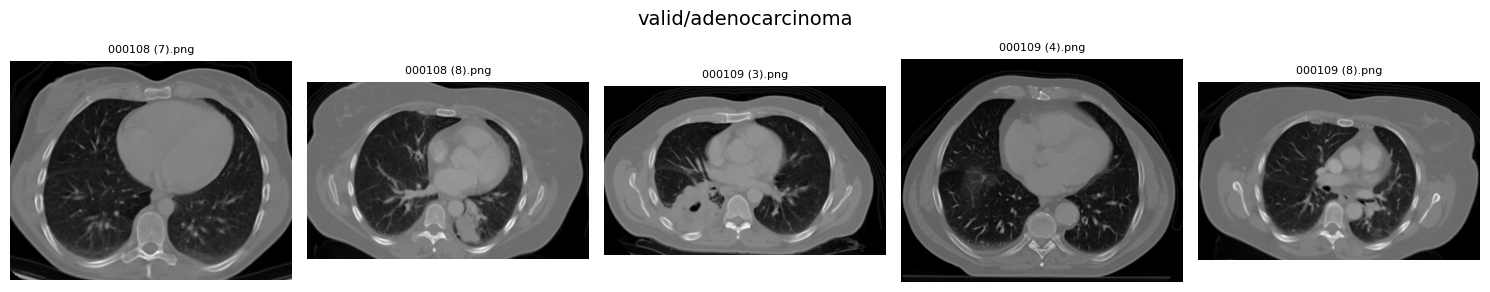


📂 valid/large.cell.carcinoma:


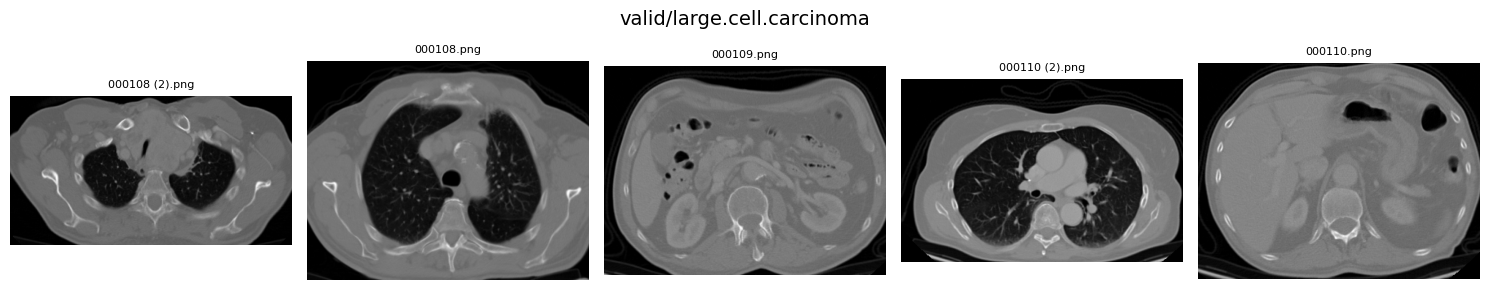


📂 valid/normal:


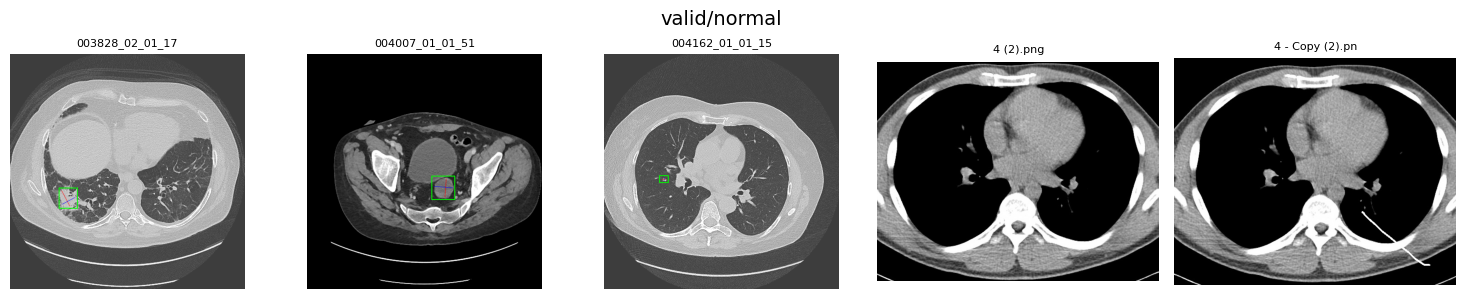


📂 valid/squamous.cell.carcinoma:


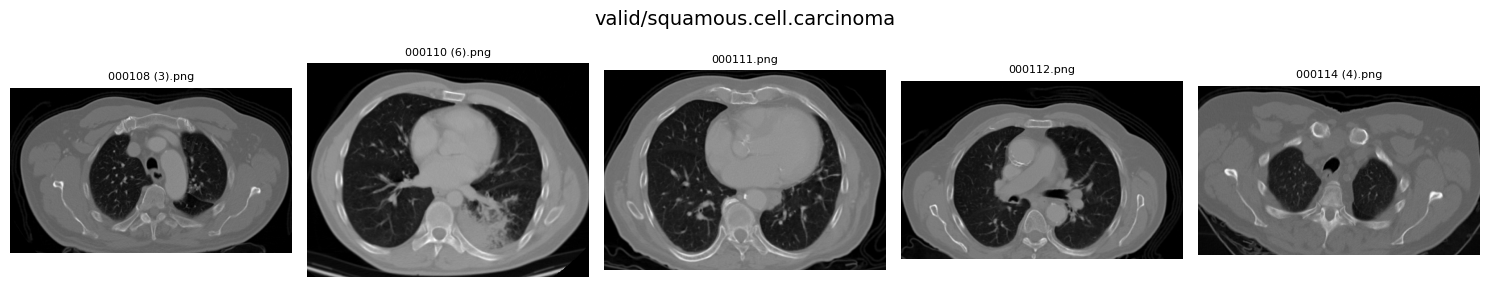


📂 test/adenocarcinoma:


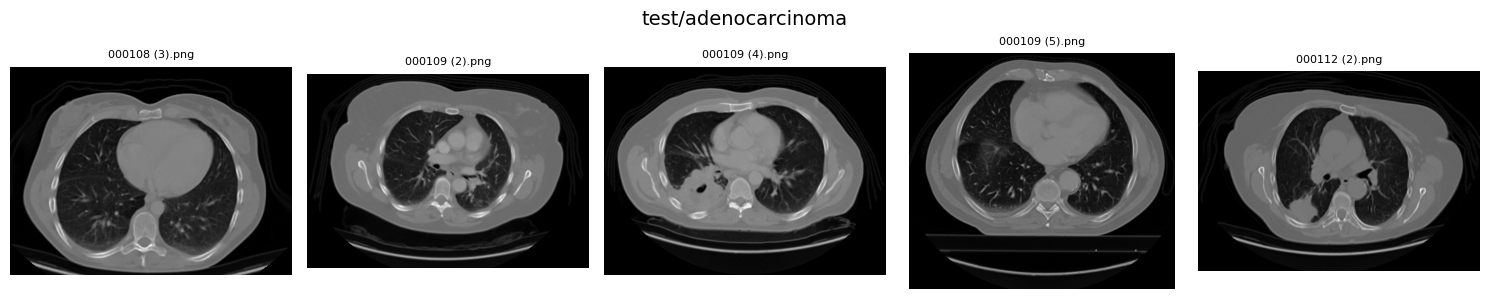


📂 test/large.cell.carcinoma:


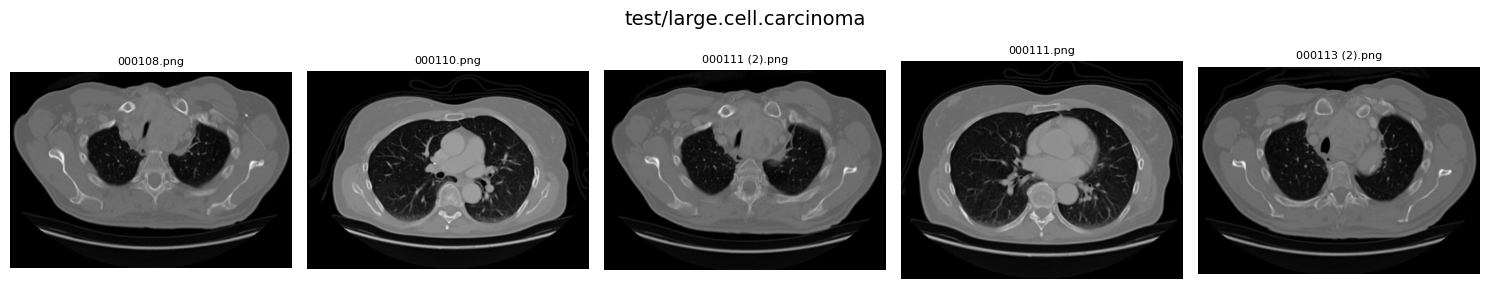


📂 test/normal:


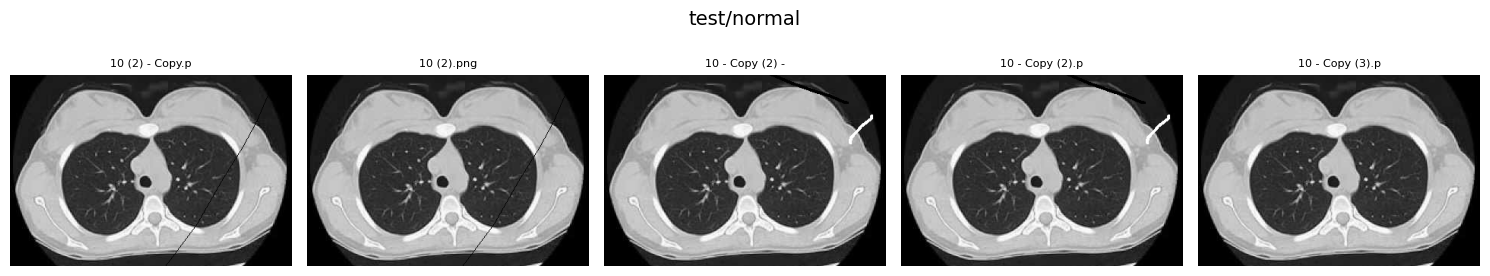


📂 test/squamous.cell.carcinoma:


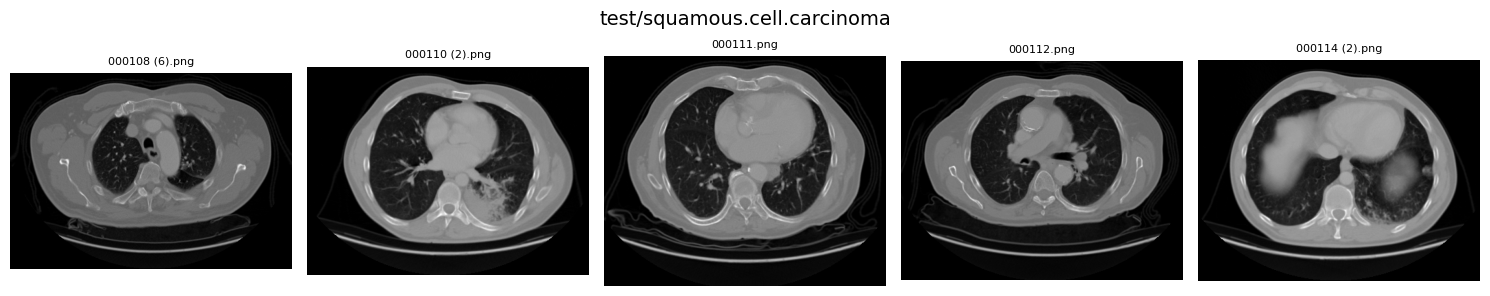

In [3]:
dataset_root = Path("./Data")

# Función para mostrar imágenes por subcarpeta sin importar el label
def mostrar_5_imagenes_por_subcarpeta(data_dir, subsets=["train", "valid", "test"]):
    for subset in subsets:
        subset_path = Path(data_dir) / subset
        if not subset_path.exists():
            print(f"[ADVERTENCIA] No existe el directorio {subset_path}")
            continue

        subfolders = [f for f in subset_path.iterdir() if f.is_dir()]
        for subfolder in subfolders:
            image_files = sorted([f for f in subfolder.iterdir() if f.is_file()])[:5]
            if not image_files:
                continue

            print(f"\n📂 {subset}/{subfolder.name}:")
            fig, axes = plt.subplots(1, len(image_files), figsize=(3 * len(image_files), 3))
            fig.suptitle(f"{subset}/{subfolder.name}", fontsize=14)

            if len(image_files) == 1:
                axes = [axes]

            for i, img_path in enumerate(image_files):
                img = cv2.imread(str(img_path))
                if img is None:
                    axes[i].axis("off")
                    axes[i].set_title("Error de lectura", fontsize=8)
                    continue
                img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                axes[i].imshow(img)
                axes[i].axis("off")
                axes[i].set_title(img_path.name[:15], fontsize=8)

            plt.tight_layout()
            plt.show()

# Ejecutar la función
mostrar_5_imagenes_por_subcarpeta(dataset_root)

### Podemos visualizar que algunas imágenes de la carpeta `valid` estan en RGB.

#### Procedemos a verificar si hay duplicados.

Se realizó una inspección sobre las imágenes del dataset y se pudo constatar que, en el caso de los distintos tipos de cáncer, no existen duplicados. Las imágenes que comparten el mismo identificador numérico corresponden al mismo estudio torácico, pero capturado desde diferentes cortes o ángulos. Esta diversidad de vistas permite una mejor visualización y análisis de la enfermedad desde distintas perspectivas.

Justificación de la conservación de imágenes similares
Se realizó una inspección visual del dataset y se comprobó que, en el caso de las clases con distintos tipos de cáncer, no hay imágenes duplicadas reales. Aquellas que comparten el mismo número base corresponden a cortes diferentes del mismo estudio torácico, permitiendo observar la enfermedad desde múltiples ángulos.

Durante el análisis también se detectaron imágenes con nombres similares (como aquellas que contienen copy o (2)), especialmente en la clase normal. Aunque algunas pueden parecer duplicadas, presentan pequeñas diferencias como anotaciones, marcas o variaciones de contraste. Estas diferencias enriquecen el conjunto de datos con ejemplos más realistas, por lo que se decidió conservar todas las imágenes.

A continuación se presentan dos ejemplos representativos de esta situación.

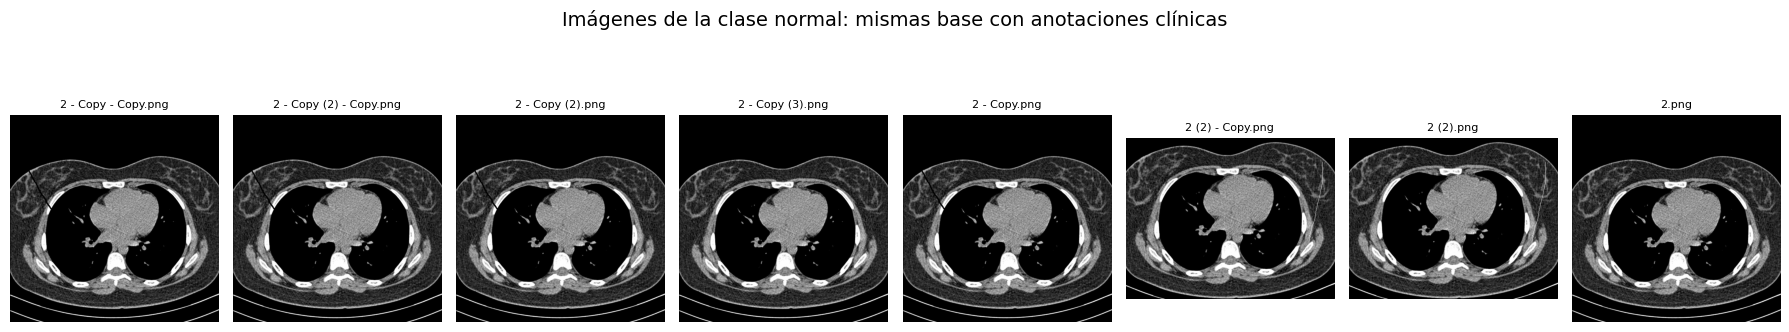

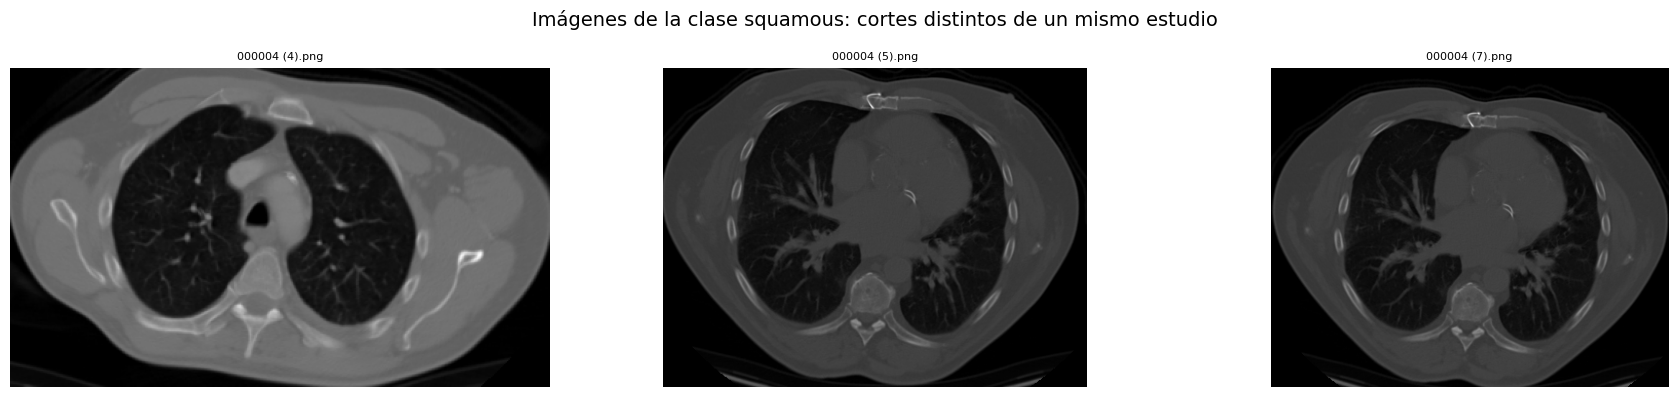

In [4]:
import matplotlib.pyplot as plt
from PIL import Image
from pathlib import Path

def mostrar_imagenes_por_nombres(ruta_clase, nombres_archivos, titulo_fila):
    fig, axes = plt.subplots(1, len(nombres_archivos), figsize=(18, 4))
    fig.suptitle(titulo_fila, fontsize=14)

    for ax, nombre in zip(axes, nombres_archivos):
        ruta_img = Path(ruta_clase) / nombre
        with Image.open(ruta_img) as img:
            ax.imshow(img, cmap='gray')
            ax.set_title(nombre, fontsize=8)
            ax.axis("off")
    plt.tight_layout()
    plt.show()

# Carpeta base
base_path = "Data/train"

# Imágenes de la clase 'normal'
imagenes_normal = [
    "2 - Copy - Copy.png",
    "2 - Copy (2) - Copy.png",
    "2 - Copy (2).png",
    "2 - Copy (3).png",
    "2 - Copy.png",
    "2 (2) - Copy.png",
    "2 (2).png",
    "2.png"
]
mostrar_imagenes_por_nombres(
    ruta_clase=f"{base_path}/normal",
    nombres_archivos=imagenes_normal,
    titulo_fila="Imágenes de la clase normal: mismas base con anotaciones clínicas"
)

# Imágenes de la clase 'squamous'
imagenes_squamous = [
    "000004 (4).png",
    "000004 (5).png",
    "000004 (7).png"
]

base_path = Path(base_path) 

# Opciones de carpeta posibles
carpetas_opcionales = [
    "squamous.cell.carcinoma_left.hilum_T1_N2_M0_IIIa",
    "squamous.cell.carcinoma"
]

# Buscar la primera carpeta existente
ruta_clase = None
for nombre in carpetas_opcionales:
    posible_ruta = base_path / nombre
    if posible_ruta.exists():
        ruta_clase = posible_ruta
        break

if ruta_clase is None:
    print("No se encontró ninguna de las carpetas esperadas.")
else:
    mostrar_imagenes_por_nombres(
        ruta_clase=ruta_clase,
        nombres_archivos=imagenes_squamous,
        titulo_fila="Imágenes de la clase squamous: cortes distintos de un mismo estudio"
    )


#### Procedemos a verificar los tamaños de las imágenes del dataset.

In [5]:
splits = ["train", "valid", "test"]
labels = ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']


def obtener_dimensiones_imagenes(dataset_root, splits, labels, max_imgs=4):
    dimensiones = []

    for split in splits:
        for label in labels:
            folder = dataset_root / split / label
            if not folder.exists():
                continue
            image_files = sorted([f for f in folder.iterdir() if f.is_file()])[:max_imgs]
            for img_path in image_files:
                img = cv2.imread(str(img_path))
                if img is not None:
                    dimensiones.append((split, label, img.shape[0], img.shape[1]))  # alto, ancho

    return dimensiones

# Obtener dimensiones
dims = obtener_dimensiones_imagenes(dataset_root, splits, labels)

# 1. Convertir la lista a DataFrame
df_dims = pd.DataFrame(dims, columns=["split", "label", "height", "width"])

# 2. Agrupar y ocultar el contador (sin eliminar filas)
df_dims_grouped = df_dims.groupby(["split", "label", "height", "width"]).size().reset_index()

# 3. Ocultar la columna del contador (la última)
df_dims_grouped = df_dims_grouped.iloc[:, :-1]

# 4. Mostrar
df_dims_grouped

,split,label,height,width
0,test,adenocarcinoma,282,381
1,test,adenocarcinoma,335,486
2,test,adenocarcinoma,357,483
3,test,adenocarcinoma,406,456
4,test,large.cell.carcinoma,285,411
5,test,large.cell.carcinoma,296,417
6,test,large.cell.carcinoma,305,395
7,test,large.cell.carcinoma,308,438
8,test,normal,251,371
9,test,squamous.cell.carcinoma,314,425


### Podemos observar que las imágenes tienen diferentes tamaños. Ahora se procede a analizar si las clases estan desbalanceadas

In [6]:
# Ruta relativa a la carpeta Data
data_dir = os.path.join(".", "Data")
subsets = ['train', 'test', 'valid']

# Contador de imágenes por clase
image_counts = defaultdict(dict)

for subset in subsets:
    subset_path = os.path.join(data_dir, subset)
    if not os.path.exists(subset_path):
        continue
    for class_name in os.listdir(subset_path):
        class_path = os.path.join(subset_path, class_name)
        if os.path.isdir(class_path):
            image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
            image_counts[class_name][subset] = len(image_files)

# Crear DataFrame
image_counts_df = pd.DataFrame(image_counts).T.fillna(0).astype(int)
image_counts_df.index.name = 'Clase'
image_counts_df.columns.name = 'Subset'

# Mostrar tabla
print(image_counts_df)

Subset                   train  test  valid
Clase                                      
adenocarcinoma             195   120     23
large.cell.carcinoma       115    51     21
normal                     148    54     13
squamous.cell.carcinoma    155    90     15


#### Hay desbalanceo en todas las clases en `valid`

---

### LIMPIEZA

#### Procedemos a generalizar los nombres de las carpetas

In [7]:
# Definir etiquetas válidas
labels = ['adenocarcinoma', 'large.cell.carcinoma', 'normal', 'squamous.cell.carcinoma']

# Función para encontrar el nombre de etiqueta a partir del nombre de carpeta
def find_label_from_folder(folder_name, labels):
    for label in labels:
        if folder_name.startswith(label):
            return label
    return None

# Particiones donde renombrar carpetas
splits_to_fix = ["train", "valid"]
base_path = os.path.join(".", "Data")

# Renombrar carpetas
for split in splits_to_fix:
    split_path = os.path.join(base_path, split)
    for folder_name in os.listdir(split_path):
        full_path = os.path.join(split_path, folder_name)
        if not os.path.isdir(full_path):
            continue
        label = find_label_from_folder(folder_name, labels)
        if label and folder_name != label:
            new_path = os.path.join(split_path, label)
            if not os.path.exists(new_path):
                shutil.move(full_path, new_path)
            else:
                # Si ya existe, mover los archivos a la carpeta correcta y eliminar la original
                for file in os.listdir(full_path):
                    shutil.move(os.path.join(full_path, file), os.path.join(new_path, file))
                os.rmdir(full_path)

# Verificamos la nueva estructura
fixed_structure = {}
for split in splits_to_fix:
    split_path = os.path.join(base_path, split)
    fixed_structure[split] = sorted(os.listdir(split_path))

fixed_structure

{'train': ['adenocarcinoma',
  'large.cell.carcinoma',
  'normal',
  'squamous.cell.carcinoma'],
 'valid': ['adenocarcinoma',
  'large.cell.carcinoma',
  'normal',
  'squamous.cell.carcinoma']}

---

#### ANÁLISIS ESTADÍSTICOS

In [8]:
# Analizar dimensiones y estadísticas de intensidad por clase
image_shapes = []
intensity_stats = []

# Vamos a recorrer sólo el conjunto de entrenamiento (train) para este análisis
subset = "train"
subset_path = os.path.join(".", "Data", subset)

for class_name in os.listdir(subset_path):
    class_path = os.path.join(subset_path, class_name)
    if not os.path.isdir(class_path):
        continue
    for img_file in os.listdir(class_path):
        if img_file.lower().endswith(('.png', '.jpg', '.jpeg')):
            img_path = os.path.join(class_path, img_file)
            img = Image.open(img_path).convert("L")  # Escala de grises
            img_array = np.array(img)

            # Guardar dimensiones
            image_shapes.append(img_array.shape)

            # Guardar estadísticas
            intensity_stats.append({
                "class": class_name,
                "mean": img_array.mean(),
                "std": img_array.std(),
                "min": img_array.min(),
                "max": img_array.max(),
                "width": img_array.shape[1],
                "height": img_array.shape[0]
            })

# Convertir a DataFrame
intensity_df = pd.DataFrame(intensity_stats)
# Agrupamos por clase y mostramos estadísticos promedio
summary_df = intensity_df.groupby("class").agg({
    "mean": "mean",
    "std": "mean",
    "min": "min",
    "max": "max",
    "width": "mean",
    "height": "mean"
}).round(2)

# Mostrar el resultado
print("Estadísticas de Intensidad y Tamaños por Clase:\n")
print(summary_df)

Estadísticas de Intensidad y Tamaños por Clase:

                           mean    std  min  max   width  height
class                                                           
adenocarcinoma            82.60  54.65    0  255  385.57  258.27
large.cell.carcinoma      62.47  46.51    0  255  398.53  259.74
normal                   113.89  80.51    0  255  572.24  429.97
squamous.cell.carcinoma   66.72  46.33    0  255  396.50  271.38


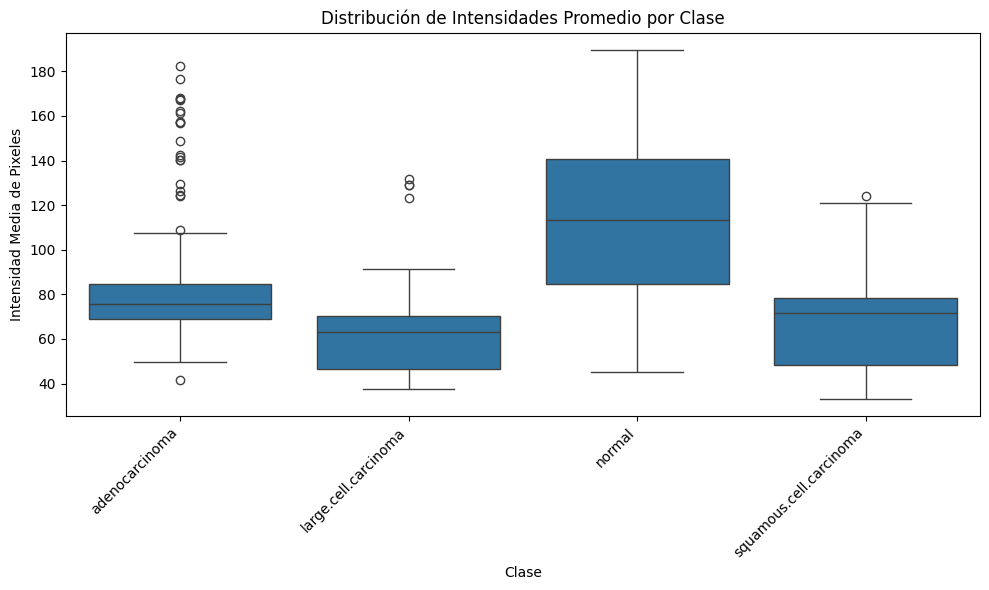

In [9]:
selected_classes = intensity_df['class'].unique()

# Crear histograma de intensidades promedio por clase
plt.figure(figsize=(10, 6))
sns.boxplot(data=intensity_df, x="class", y="mean")
plt.title("Distribución de Intensidades Promedio por Clase")
plt.ylabel("Intensidad Media de Pixeles")
plt.xlabel("Clase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()


### Análisis del Boxplot: Intensidad Media por Clase

El gráfico de cajas muestra la distribución de la intensidad promedio de píxeles por clase en el conjunto de entrenamiento:

- **Normal**: Tiene las intensidades más altas (mediana > 110), con una amplia dispersión y varios valores atípicos por encima de 180. Esto indica una mayor luminosidad general en pulmones sanos.
- **Adenocarcinoma** y **Squamous cell carcinoma**: Presentan medianas entre 70 y 80, con distribución más compacta. Reflejan menor brillo debido a la presencia de masas o lesiones.
- **Large cell carcinoma**: Es la clase con menor intensidad media (mediana < 70), lo que podría asociarse a imágenes más oscuras o tumores densos.

**Conclusión**: La intensidad promedio puede ser un buen descriptor para distinguir entre imágenes normales y patológicas, aunque entre subtipos de cáncer hay solapamientos.

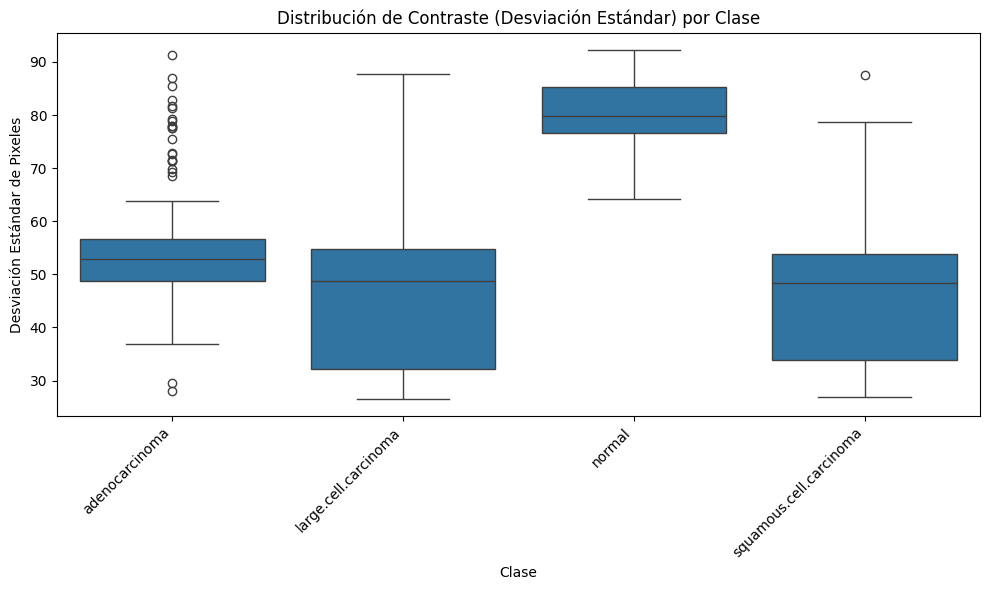

In [10]:
# Histograma de la desviación estándar por clase
plt.figure(figsize=(10, 6))
sns.boxplot(data=intensity_df, x="class", y="std")
plt.title("Distribución de Contraste (Desviación Estándar) por Clase")
plt.ylabel("Desviación Estándar de Pixeles")
plt.xlabel("Clase")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

### Análisis: Desviación Estándar por Clase (Contraste)

Este gráfico muestra la variabilidad en la intensidad de píxeles, lo que se traduce en el **contraste** de las imágenes:

- **Normal**: Presenta la mayor dispersión de valores (`std ≈ 75–90`), lo que indica imágenes más ricas en variaciones de gris. Esto es consistente con pulmones sanos que contienen más detalles estructurales visibles.
- **Clases patológicas** (adenocarcinoma, large cell, squamous cell): Tienen menor contraste, con medianas entre `50–55`, lo que puede deberse a la homogeneidad visual de las lesiones.
- **Large cell carcinoma**: Se destaca por su menor rango de variación (`std ≈ 30–60`), lo que puede indicar lesiones más opacas o compactas.

**Conclusión**: Las imágenes normales tienden a tener mayor contraste, lo cual puede ser útil para diferenciarlas automáticamente de las patológicas.


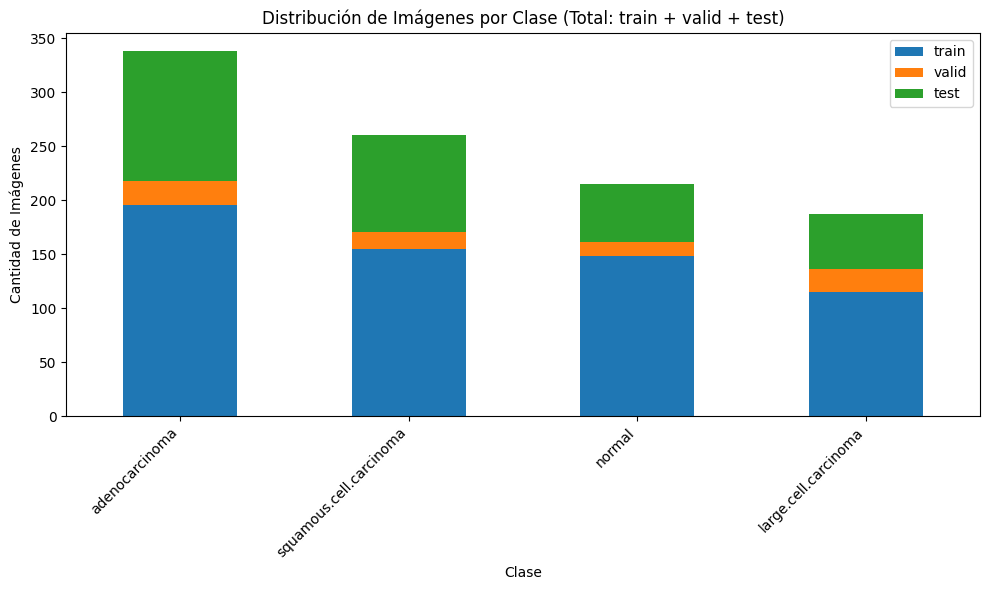

,train,valid,test,total
adenocarcinoma,195,23,120,338
squamous.cell.carcinoma,155,15,90,260
normal,148,13,54,215
large.cell.carcinoma,115,21,51,187


In [11]:
subsets = ["train", "valid", "test"]
class_distribution = defaultdict(lambda: {"train": 0, "valid": 0, "test": 0})

for subset in subsets:
    subset_path = os.path.join(dataset_root, subset)
    for class_name in os.listdir(subset_path):
        class_path = os.path.join(subset_path, class_name)
        if os.path.isdir(class_path):
            count = len([
                f for f in os.listdir(class_path)
                if f.lower().endswith(('.png', '.jpg', '.jpeg'))
            ])
            class_distribution[class_name][subset] = count

# Convertir a DataFrame
df_balance = pd.DataFrame(class_distribution).T.fillna(0).astype(int)
df_balance["total"] = df_balance.sum(axis=1)
df_balance = df_balance.sort_values("total", ascending=False)

# Graficar
df_balance[["train", "valid", "test"]].plot(kind="bar", stacked=True, figsize=(10, 6))
plt.title("Distribución de Imágenes por Clase (Total: train + valid + test)")
plt.xlabel("Clase")
plt.ylabel("Cantidad de Imágenes")
plt.xticks(rotation=45, ha="right")
plt.tight_layout()
plt.show()

# Mostrar tabla
df_balance

### Análisis de Balance de Clases (Train + Valid + Test)

- **Las clases están desbalanceadas** en cuanto al número total de imágenes:
  - **Adenocarcinoma** (`218`) y **Normal** (`215`) están ligeramente por encima.
  - **Squamous cell carcinoma** (`170`) y **Large cell carcinoma** (`136`) tienen menor representación.
  - En el conjunto `test`, las clases están etiquetadas de forma genérica y no se solapan con las usadas en `train`/`valid`.

- Las clases de `test` (`adenocarcinoma`, `large.cell.carcinoma`, etc.) no están presentes en `train`, lo que implica que el conjunto `test` usa otra nomenclatura. Esto puede requerir mapear o fusionar nombres si se desea una evaluación conjunta.

#### Conclusión:

El dataset **presenta cierto desbalance**, principalmente entre subtipos de cáncer.

----

#### PREPROCESAMIENTO

In [14]:
from torchvision import datasets, transforms
from torch.utils.data import DataLoader

extract_path = "./" 

# Transformaciones con normalización para DenseNet121
image_size = 224
batch_size = 8

transform_train = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

transform_val_test = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.485, 0.456, 0.406],
                         std=[0.229, 0.224, 0.225])
])

# Cargar datasets desde carpetas y convertir imágenes a RGB
def rgb_loader(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')

train_dataset = datasets.ImageFolder(os.path.join(extract_path, "Data", "train"),
                                     transform=transform_train,
                                     loader=rgb_loader)

valid_dataset = datasets.ImageFolder(os.path.join(extract_path, "Data", "valid"),
                                     transform=transform_val_test,
                                     loader=rgb_loader)

test_dataset = datasets.ImageFolder(os.path.join(extract_path, "Data", "test"),
                                    transform=transform_val_test,
                                    loader=rgb_loader)

# Crear dataloaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=12)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=12)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=12)

# Verificar clases y tamaño
{
    "Clases": train_dataset.classes,
    "Cantidad de imágenes": {
        "train": len(train_dataset),
        "valid": len(valid_dataset),
        "test": len(test_dataset)
    }
}

{'Clases': ['adenocarcinoma',
  'large.cell.carcinoma',
  'normal',
  'squamous.cell.carcinoma'],
 'Cantidad de imágenes': {'train': 613, 'valid': 72, 'test': 315}}

In [ ]:
import torch
import torch.nn as nn

# Verificar si hay GPU disponible
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar modelo DenseNet121 preentrenado en ImageNet
model = densenet121(weights=True)

# Congelar todas las capas del modelo excepto el último bloque
for param in model.parameters():
    param.requires_grad = False

# Descongelar el último bloque convolucional y batch norm
for param in model.features.denseblock4.parameters():
    param.requires_grad = True
for param in model.features.norm5.parameters():
    param.requires_grad = True

# Reemplazar la capa final del clasificador para 4 clases
num_features = model.classifier.in_features
model.classifier = nn.Linear(num_features, 4)  # 4 clases

# Enviar a dispositivo (GPU o CPU)
model = model.to(device)

# Definir función de pérdida y optimizador
criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(filter(lambda p: p.requires_grad, model.parameters()), lr=1e-4)

# Resumen del modelo
{
    "Modelo": "DenseNet121",
    "Capas entrenables": sum(p.numel() for p in model.parameters() if p.requires_grad),
    "Capas totales": sum(p.numel() for p in model.parameters())
}

{'Modelo': 'DenseNet121',
 'Capas entrenables': 2164228,
 'Capas totales': 6957956}

In [16]:
# Función de entrenamiento
from copy import deepcopy

def train_model(model, criterion, optimizer, train_loader, valid_loader, device, num_epochs=10):
    best_model_wts = deepcopy(model.state_dict())
    best_acc = 0.0
    train_history, val_history = [], []

    for epoch in range(num_epochs):
        print(f'\n Epoch {epoch+1}/{num_epochs}')
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        train_history.append((epoch_loss, epoch_acc.item()))
        print(f'Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_loss /= len(valid_loader.dataset)
        val_acc = val_corrects.double() / len(valid_loader.dataset)
        val_history.append((val_loss, val_acc.item()))
        print(f'Valid Loss: {val_loss:.4f} | Acc: {val_acc:.4f}')

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = deepcopy(model.state_dict())
            print("Mejor modelo actualizado")

    model.load_state_dict(best_model_wts)
    return model, train_history, val_history

# Entrenar
trained_model, train_metrics, val_metrics = train_model(
    model, criterion, optimizer, train_loader, valid_loader, device, num_epochs=10
)


 Epoch 1/10
Train Loss: 1.0129 | Acc: 0.5987
Valid Loss: 0.8687 | Acc: 0.6111
Mejor modelo actualizado

 Epoch 2/10
Train Loss: 0.6874 | Acc: 0.7439
Valid Loss: 0.7048 | Acc: 0.7222
Mejor modelo actualizado

 Epoch 3/10
Train Loss: 0.5369 | Acc: 0.8173
Valid Loss: 0.5588 | Acc: 0.7778
Mejor modelo actualizado

 Epoch 4/10
Train Loss: 0.4274 | Acc: 0.8825
Valid Loss: 0.4408 | Acc: 0.8750
Mejor modelo actualizado

 Epoch 5/10
Train Loss: 0.2991 | Acc: 0.9086
Valid Loss: 0.4138 | Acc: 0.8472

 Epoch 6/10
Train Loss: 0.2286 | Acc: 0.9396
Valid Loss: 0.4108 | Acc: 0.8889
Mejor modelo actualizado

 Epoch 7/10
Train Loss: 0.2352 | Acc: 0.9331
Valid Loss: 0.3696 | Acc: 0.9028
Mejor modelo actualizado

 Epoch 8/10
Train Loss: 0.1752 | Acc: 0.9592
Valid Loss: 0.3989 | Acc: 0.8889

 Epoch 9/10
Train Loss: 0.1704 | Acc: 0.9429
Valid Loss: 0.3731 | Acc: 0.9028

 Epoch 10/10
Train Loss: 0.1464 | Acc: 0.9625
Valid Loss: 0.3627 | Acc: 0.9167
Mejor modelo actualizado


----

### ResNet50

In [19]:
# Transforms
image_size = 224
batch_size = 8
transform_train = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
transform_val_test = transforms.Compose([
    transforms.Resize((image_size, image_size)),
    transforms.ToTensor(),
    transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
])
def rgb_loader(path):
    with open(path, 'rb') as f:
        img = Image.open(f)
        return img.convert('RGB')

# Datasets
train_dataset = datasets.ImageFolder(os.path.join(extract_path, "Data", "train"), transform=transform_train, loader=rgb_loader)
valid_dataset = datasets.ImageFolder(os.path.join(extract_path, "Data", "valid"), transform=transform_val_test, loader=rgb_loader)
test_dataset  = datasets.ImageFolder(os.path.join(extract_path, "Data", "test"),  transform=transform_val_test, loader=rgb_loader)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=0)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, num_workers=0)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False, num_workers=0)

# Preparar modelo ResNet50
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
resnet_model = resnet50(weights=True)

# Congelar todas las capas
for param in resnet_model.parameters():
    param.requires_grad = False

# Descongelar última capa convolucional y batchnorm
for param in resnet_model.layer4.parameters():
    param.requires_grad = True
for param in resnet_model.bn1.parameters():
    param.requires_grad = True

# Reemplazar capa fully-connected final
resnet_model.fc = nn.Linear(resnet_model.fc.in_features, 4)
resnet_model = resnet_model.to(device)

# Pérdida y optimizador
criterion_resnet = nn.CrossEntropyLoss()
optimizer_resnet = torch.optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=1e-4)

In [20]:
# Función de entrenamiento
def train_model(model, criterion, optimizer, train_loader, valid_loader, device, num_epochs=10):
    best_model_wts = deepcopy(model.state_dict())
    best_acc = 0.0
    train_history, val_history = [], []

    for epoch in range(num_epochs):
        print(f'\n Epoch {epoch+1}/{num_epochs}')
        model.train()
        running_loss, running_corrects = 0.0, 0

        for inputs, labels in train_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            optimizer.zero_grad()
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            loss = criterion(outputs, labels)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * inputs.size(0)
            running_corrects += torch.sum(preds == labels.data)

        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_corrects.double() / len(train_loader.dataset)
        train_history.append((epoch_loss, epoch_acc.item()))
        print(f'Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f}')

        model.eval()
        val_loss, val_corrects = 0.0, 0
        with torch.no_grad():
            for inputs, labels in valid_loader:
                inputs, labels = inputs.to(device), labels.to(device)
                outputs = model(inputs)
                _, preds = torch.max(outputs, 1)
                loss = criterion(outputs, labels)
                val_loss += loss.item() * inputs.size(0)
                val_corrects += torch.sum(preds == labels.data)

        val_loss /= len(valid_loader.dataset)
        val_acc = val_corrects.double() / len(valid_loader.dataset)
        val_history.append((val_loss, val_acc.item()))
        print(f'Valid Loss: {val_loss:.4f} | Acc: {val_acc:.4f}')

        if val_acc > best_acc:
            best_acc = val_acc
            best_model_wts = deepcopy(model.state_dict())
            print("Mejor modelo actualizado")

    model.load_state_dict(best_model_wts)
    return model, train_history, val_history

# Entrenar ResNet50
trained_resnet, resnet_train_metrics, resnet_val_metrics = train_model(
    resnet_model, criterion_resnet, optimizer_resnet,
    train_loader, valid_loader, device, num_epochs=10
)


 Epoch 1/10
Train Loss: 0.8165 | Acc: 0.6558
Valid Loss: 0.6549 | Acc: 0.6944
Mejor modelo actualizado

 Epoch 2/10
Train Loss: 0.4317 | Acc: 0.8499
Valid Loss: 0.3974 | Acc: 0.8333
Mejor modelo actualizado

 Epoch 3/10
Train Loss: 0.2877 | Acc: 0.8956
Valid Loss: 0.3967 | Acc: 0.8750
Mejor modelo actualizado

 Epoch 4/10
Train Loss: 0.2086 | Acc: 0.9201
Valid Loss: 0.4336 | Acc: 0.8611

 Epoch 5/10
Train Loss: 0.1691 | Acc: 0.9543
Valid Loss: 0.4845 | Acc: 0.8611

 Epoch 6/10
Train Loss: 0.1295 | Acc: 0.9543
Valid Loss: 0.4454 | Acc: 0.8750

 Epoch 7/10
Train Loss: 0.1114 | Acc: 0.9625
Valid Loss: 0.4216 | Acc: 0.9028
Mejor modelo actualizado

 Epoch 8/10
Train Loss: 0.1020 | Acc: 0.9608
Valid Loss: 0.2517 | Acc: 0.9306
Mejor modelo actualizado

 Epoch 9/10
Train Loss: 0.0705 | Acc: 0.9821
Valid Loss: 0.4707 | Acc: 0.8333

 Epoch 10/10
Train Loss: 0.0739 | Acc: 0.9788
Valid Loss: 0.3800 | Acc: 0.8889
